### Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb

import matplotlib.pyplot as plt
from matplotlib import rcParams

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV

### Data Preprocessing

In [14]:
df = pd.read_csv('2025_daily_tracker.csv')
df = df[['Mood', 'Sleep', 'Alcohol', 'Caffeine', 'Video Games', 'Weed', 'Personal Time']]

df.replace(to_replace = 'Y', value=1, inplace=True)
df.replace(to_replace = 'y', value=1, inplace=True)
df.replace(to_replace = 'Y!', value=1, inplace=True)
df.replace(to_replace = 'N', value=0, inplace=True)
df.replace(to_replace = 'n', value=0, inplace=True)

minmax = MinMaxScaler()

alcohol_X = df[['Alcohol']]
minmax.fit(alcohol_X)
df['alcohol_normalized'] = minmax.transform(alcohol_X)
df.drop(columns='Alcohol', inplace=True)

mood_X = df[['Mood']]
minmax.fit(mood_X)
df['mood_normalized'] = minmax.transform(mood_X)
df.drop(columns='Mood', inplace=True)

sleep_X = df[['Sleep']]
minmax.fit(sleep_X)
df['sleep_normalized'] = minmax.transform(sleep_X)
df.drop(columns='Sleep', inplace=True)

df.dropna(axis=0, inplace=True)
df.head()

C:\Users\sfind\AppData\Local\Temp\ipykernel_27712\1915747609.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(to_replace = 'N', value=0, inplace=True)


,Caffeine,Video Games,Weed,Personal Time,alcohol_normalized,mood_normalized,sleep_normalized
0,1,0,0,0,0.0,0.50,0.3
1,0,0,0,0,0.0,0.50,0.5
2,1,0,0,0,0.0,0.50,0.7
3,0,1,0,1,0.0,0.75,0.6
4,1,0,0,0,0.0,0.50,0.5


### Correlation Matrix

In [15]:
def corr_combined(df, file_path=None):
    rcParams['figure.figsize'] = 10,10
    plt.figure()
    numeric_bool_df = df.select_dtypes(include=[np.number, bool])
    corr_matrix = numeric_bool_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    ax = sb.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu')
    # plt.savefig(file_path)

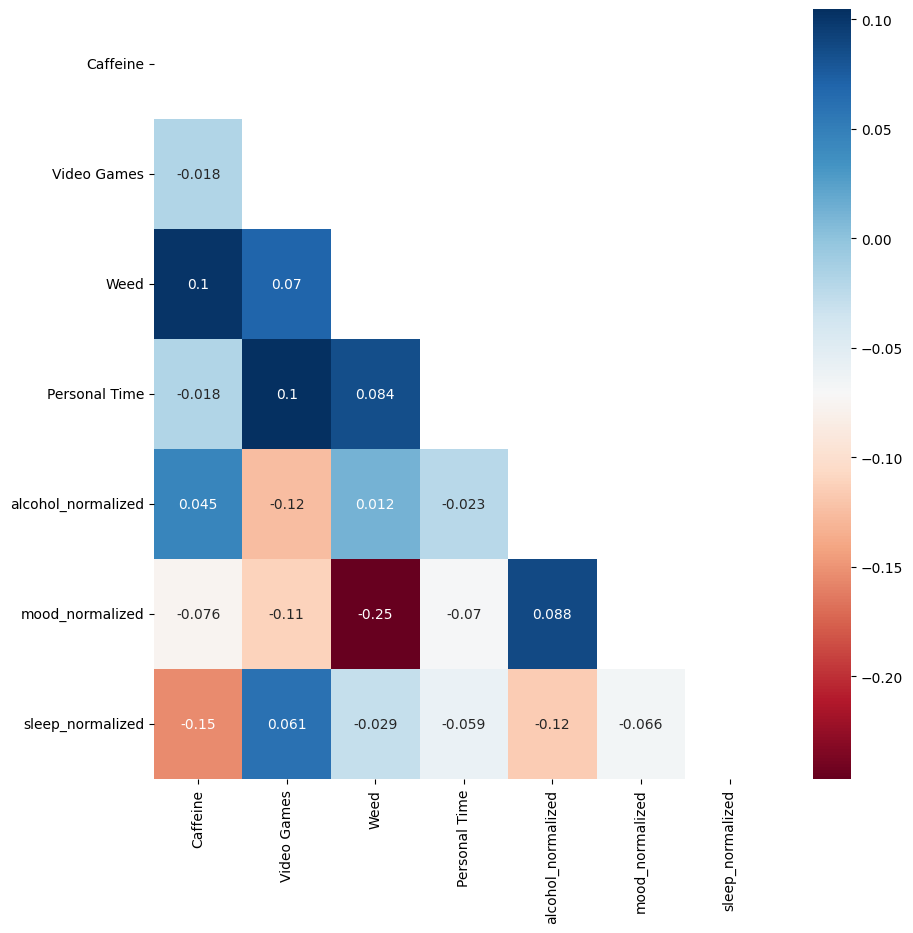

In [16]:
corr_combined(df)

### Decision Tree Regressor: Mood

In [5]:
data = df[[
    'alcohol_normalized',
    'sleep_normalized',
    # 'Caffeine',
    'Weed',
    # 'Sex',
    # 'Masturbation',
    'Video Games',
    'mood_normalized']] # Add predictor here
data.dropna(axis=0, inplace=True)

# data.info()

C:\Users\sfind\AppData\Local\Temp\ipykernel_27712\776076092.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(axis=0, inplace=True)


[Text(0.4076450892857143, 0.9583333333333334, 'Weed <= 0.5\nsquared_error = 0.022\nsamples = 289\nvalue = 0.567'),
 Text(0.1480654761904762, 0.875, 'sleep_normalized <= 0.85\nsquared_error = 0.033\nsamples = 78\nvalue = 0.619'),
 Text(0.27785528273809523, 0.9166666666666667, 'True  '),
 Text(0.13616071428571427, 0.7916666666666666, 'sleep_normalized <= 0.15\nsquared_error = 0.03\nsamples = 76\nvalue = 0.609'),
 Text(0.023809523809523808, 0.7083333333333334, 'alcohol_normalized <= 0.083\nsquared_error = 0.04\nsamples = 5\nvalue = 0.85'),
 Text(0.011904761904761904, 0.625, 'squared_error = 0.0\nsamples = 1\nvalue = 0.5'),
 Text(0.03571428571428571, 0.625, 'alcohol_normalized <= 0.25\nsquared_error = 0.012\nsamples = 4\nvalue = 0.938'),
 Text(0.023809523809523808, 0.5416666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = 1.0'),
 Text(0.047619047619047616, 0.5416666666666666, 'sleep_normalized <= 0.05\nsquared_error = 0.014\nsamples = 3\nvalue = 0.917'),
 Text(0.03571428571428571, 0.4

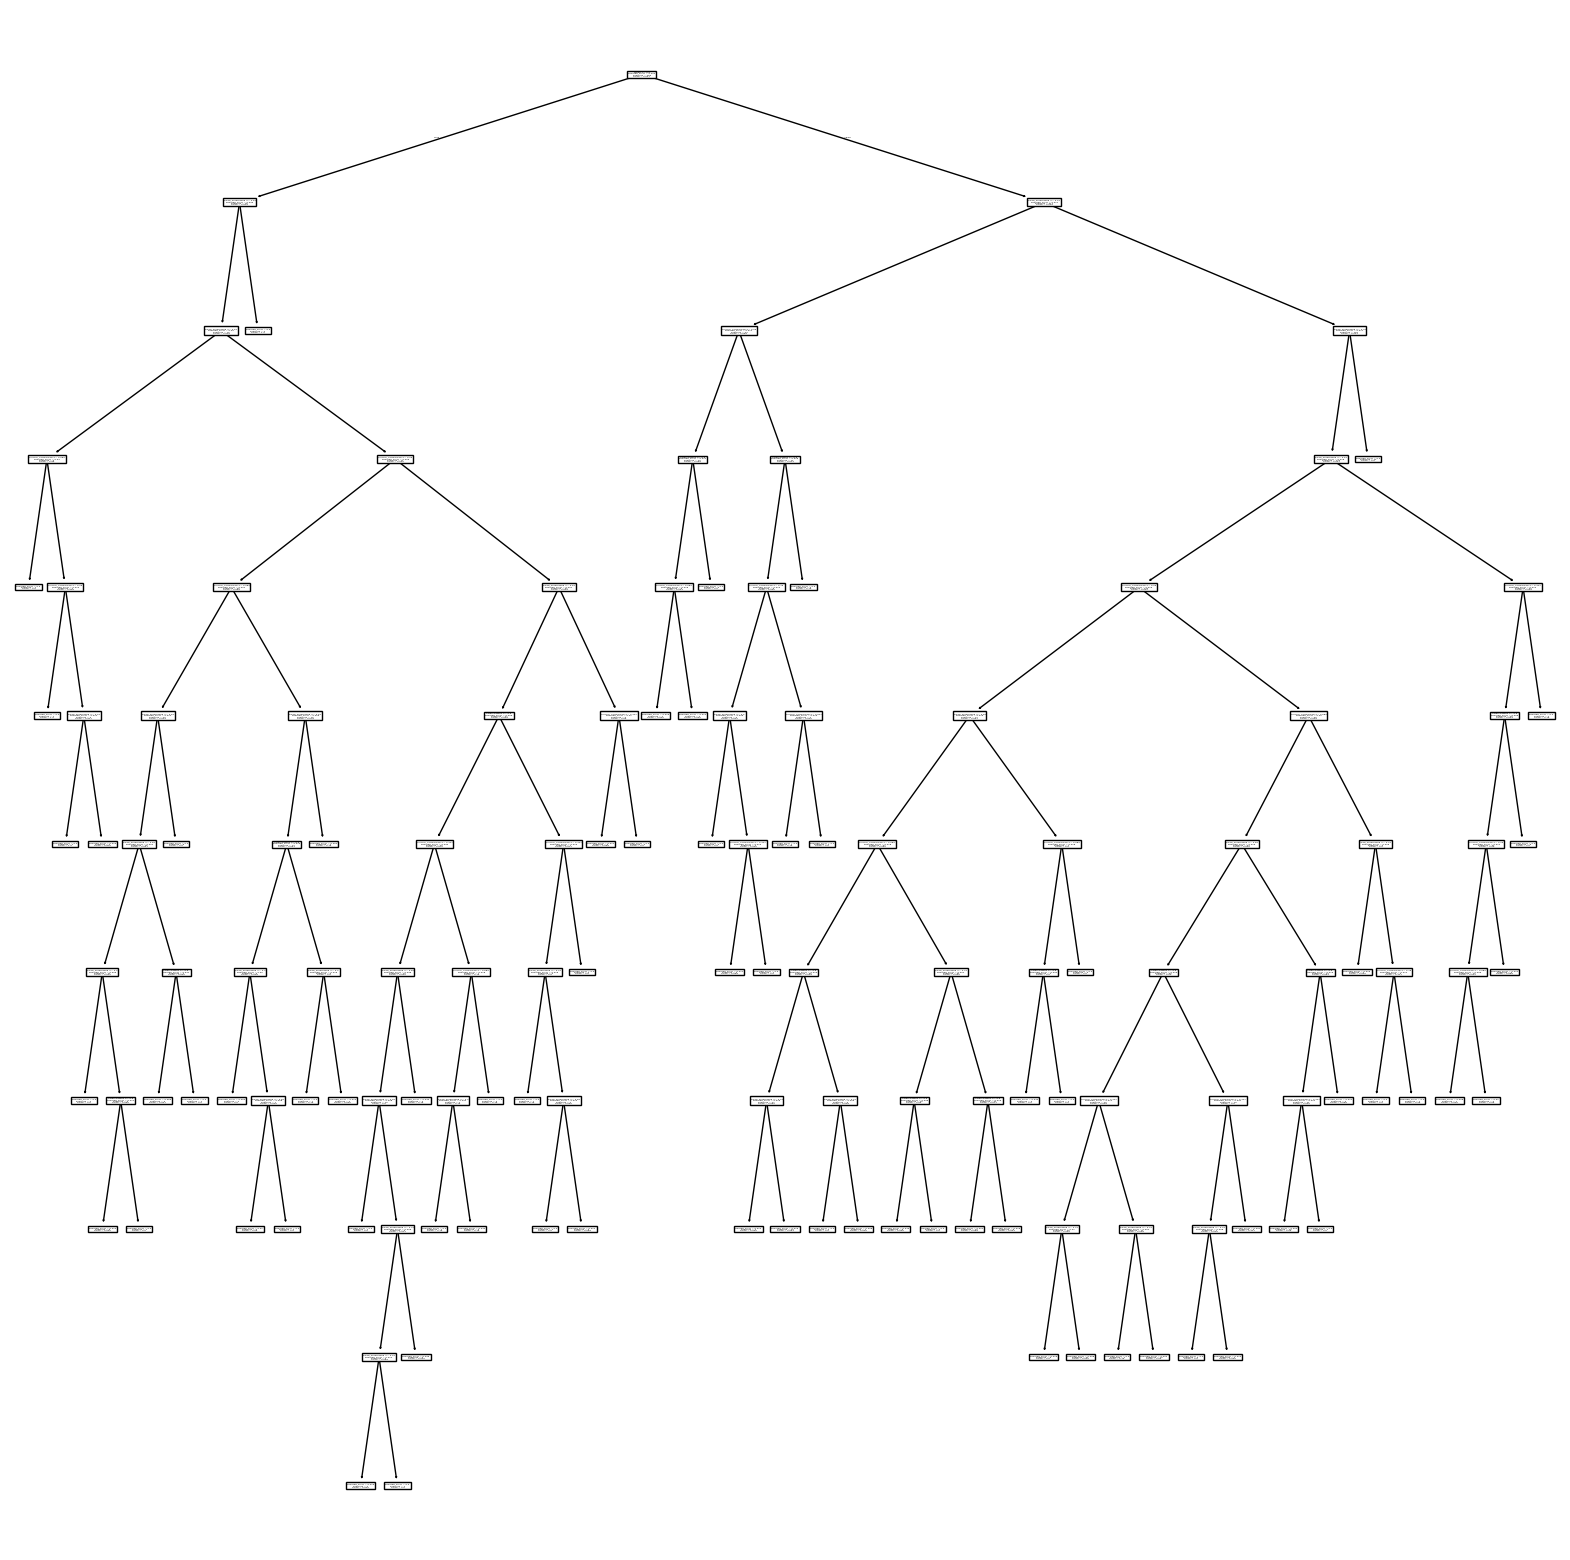

In [7]:
X = data.drop('mood_normalized', axis=1) # Modify to include your predictor
y = data['mood_normalized'] # Modify to include your predictor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # To be used in logistic/OLS

dt_best_model = DecisionTreeRegressor(random_state=42)
dt_best_model.fit(X_train, y_train)
y_pred = dt_best_model.predict(X_test)

fig,ax = plt.subplots(figsize=(20,20))
plot_tree(dt_best_model, feature_names = dt_best_model.feature_names_in_)

In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')
print(f'R2 Score: {r2}')

Mean Squared Error: 0.03166113403855709
Root Mean Squared Error: 0.1779357581784985
Mean Absolute Error: 0.1169654038139744
R2 Score: -0.21164943117752766


In [9]:
X_train = sm.add_constant(X_train)
model = sm.Logit(y_train, X_train)
result = model.fit()
summary = result.summary()
print(summary)

Optimization terminated successfully.
         Current function value: 0.670470
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        mood_normalized   No. Observations:                  289
Model:                          Logit   Df Residuals:                      284
Method:                           MLE   Df Model:                            4
Date:                Mon, 29 Dec 2025   Pseudo R-squ.:                 -0.1374
Time:                        08:23:12   Log-Likelihood:                -193.77
converged:                       True   LL-Null:                       -170.36
Covariance Type:            nonrobust   LLR p-value:                     1.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.5594      0.498      1.123      0.262      -0.417       1.536
alcoh

### Decision Tree Regressor: Alcohol

In [10]:
data = df[[
    # 'mood_normalized',
    'Weed',
    'Sex',
    'Personal Time',
    'Video Games',
    'alcohol_normalized']] # Add predictor here
data.dropna(axis=0, inplace=True)

# data.info()

C:\Users\sfind\AppData\Local\Temp\ipykernel_27712\2668613947.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(axis=0, inplace=True)


[Text(0.5333333333333333, 0.9, 'Video Games <= 0.5\nsquared_error = 0.043\nsamples = 289\nvalue = 0.227'),
 Text(0.3333333333333333, 0.7, 'Sex <= 0.5\nsquared_error = 0.047\nsamples = 217\nvalue = 0.242'),
 Text(0.43333333333333335, 0.8, 'True  '),
 Text(0.26666666666666666, 0.5, 'Weed <= 0.5\nsquared_error = 0.047\nsamples = 216\nvalue = 0.243'),
 Text(0.13333333333333333, 0.3, 'Personal Time <= 0.5\nsquared_error = 0.045\nsamples = 61\nvalue = 0.235'),
 Text(0.06666666666666667, 0.1, 'squared_error = 0.047\nsamples = 52\nvalue = 0.24'),
 Text(0.2, 0.1, 'squared_error = 0.029\nsamples = 9\nvalue = 0.204'),
 Text(0.4, 0.3, 'Personal Time <= 0.5\nsquared_error = 0.047\nsamples = 155\nvalue = 0.246'),
 Text(0.3333333333333333, 0.1, 'squared_error = 0.053\nsamples = 113\nvalue = 0.242'),
 Text(0.4666666666666667, 0.1, 'squared_error = 0.032\nsamples = 42\nvalue = 0.258'),
 Text(0.4, 0.5, 'squared_error = 0.0\nsamples = 1\nvalue = 0.0'),
 Text(0.7333333333333333, 0.7, 'Personal Time <= 0.5

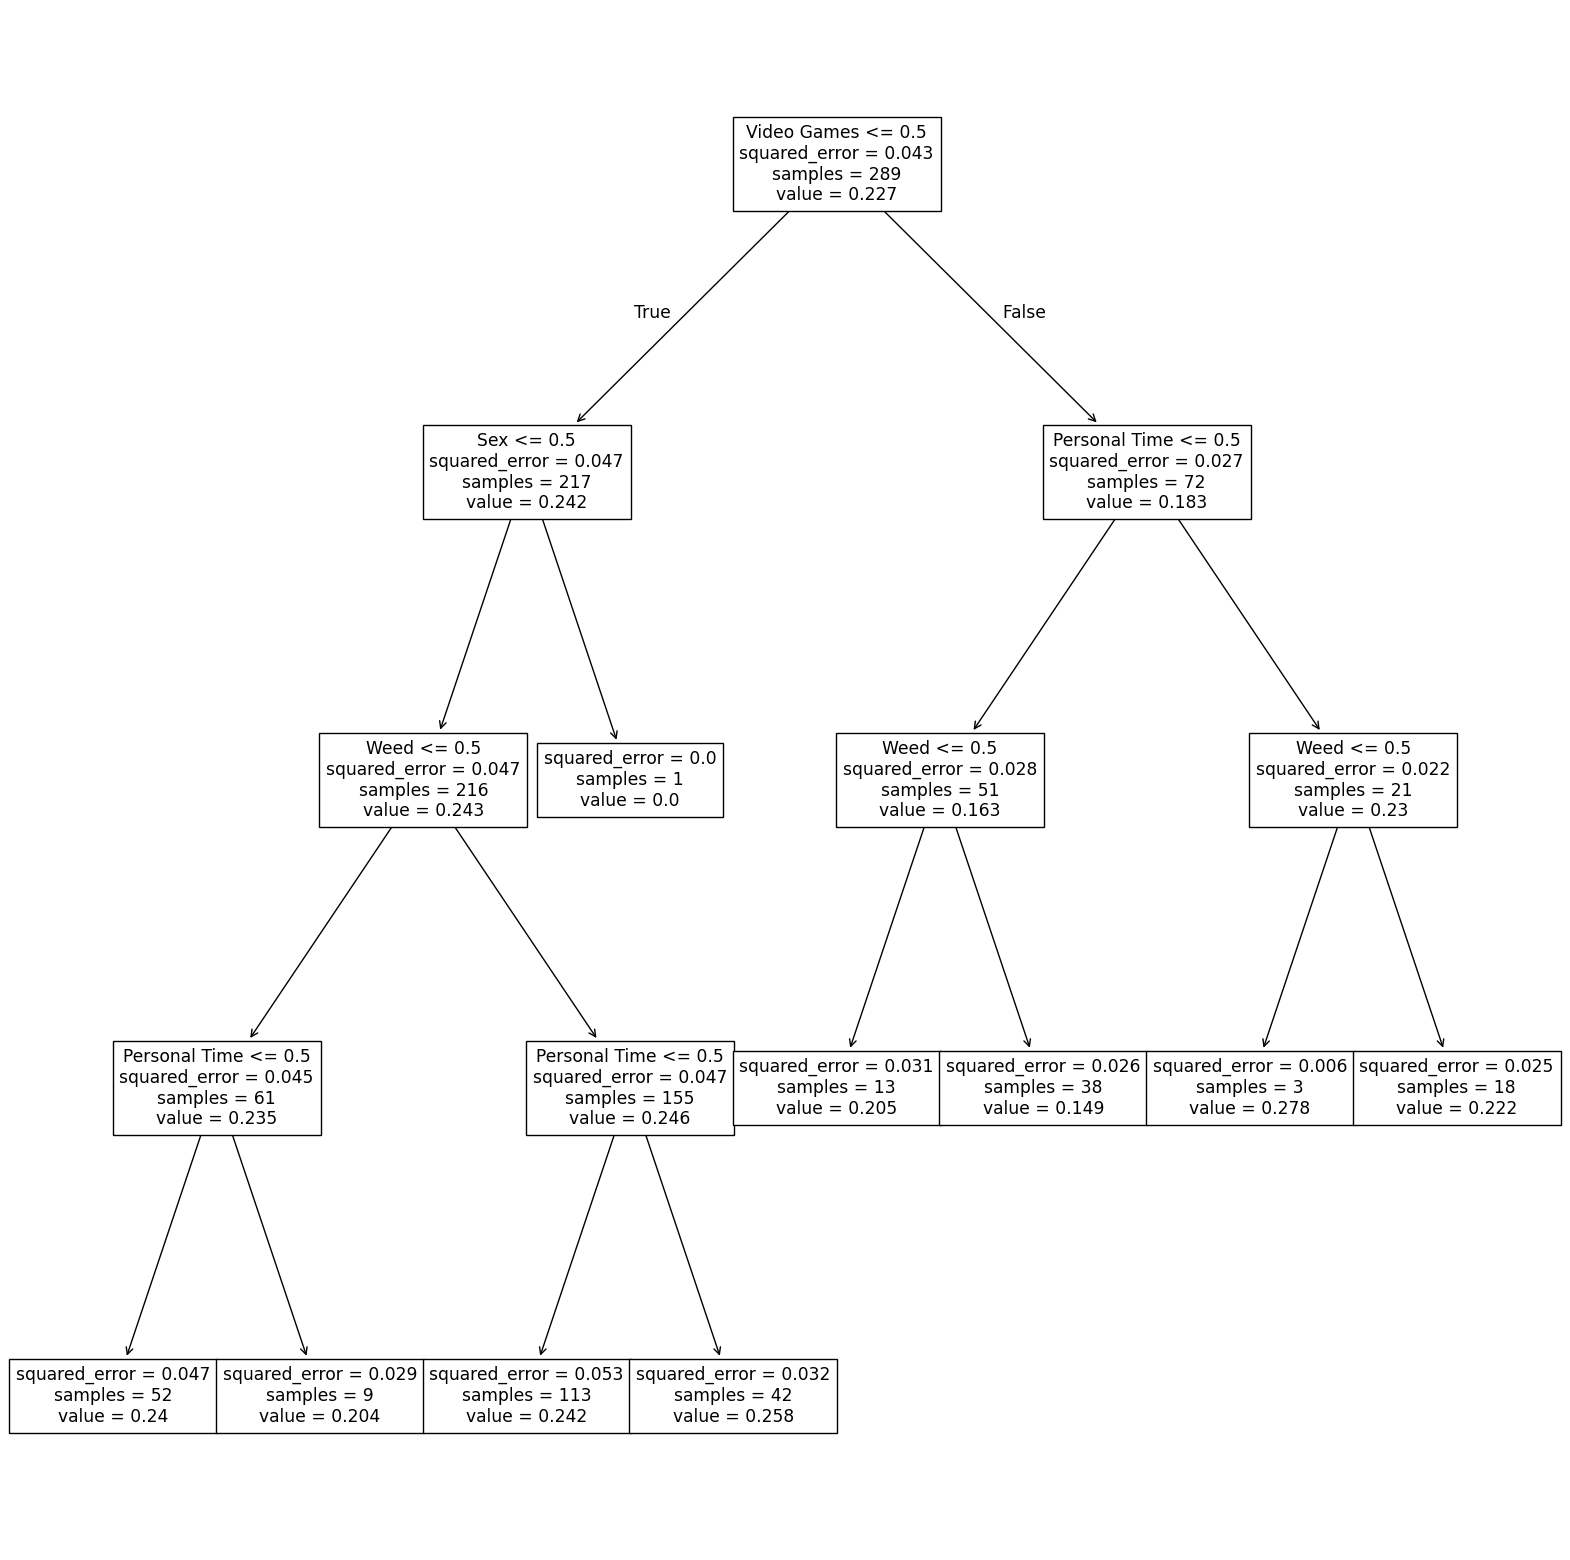

In [11]:
X = data.drop('alcohol_normalized', axis=1) # Modify to include your predictor
y = data['alcohol_normalized'] # Modify to include your predictor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # To be used in logistic/OLS

dt_best_model = DecisionTreeRegressor(random_state=42)
dt_best_model.fit(X_train, y_train)
y_pred = dt_best_model.predict(X_test)

fig,ax = plt.subplots(figsize=(20,20))
plot_tree(dt_best_model, feature_names = dt_best_model.feature_names_in_)

In [12]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')
print(f'R2 Score: {r2}')

Mean Squared Error: 0.04549682617750749
Root Mean Squared Error: 0.21329985039260457
Mean Absolute Error: 0.17613966080127844
R2 Score: -0.002560661750258042


In [13]:
X_train = sm.add_constant(X_train)
model = sm.Logit(y_train, X_train)
result = model.fit()
summary = result.summary()
print(summary)

         Current function value: 0.440104
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:     alcohol_normalized   No. Observations:                  289
Model:                          Logit   Df Residuals:                      284
Method:                           MLE   Df Model:                            4
Date:                Mon, 29 Dec 2025   Pseudo R-squ.:                 -0.6519
Time:                        08:23:13   Log-Likelihood:                -127.19
converged:                      False   LL-Null:                       -76.998
Covariance Type:            nonrobust   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.1506      0.282     -4.083      0.000      -1.703      -0.598
Weed             -0.0255      0.320     -0.080      0.93

c:\Users\sfind\Downloads\PersonalProjects\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
